In [5]:
# Load Dataset
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X.shape

(442, 10)

In [6]:
# select only one feature
X = X[:, [2]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

X_train.shape


(422, 1)

In [8]:
from sklearn import linear_model

reg_model = linear_model.LinearRegression()

In [9]:
reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[938.24]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[0.98]


In [10]:
y_pred = reg_model.predict(X_test)
y_pred

array([225.9732401 , 115.74763374, 163.27610621, 114.73638965,
       120.80385422, 158.21988574, 236.08568105, 121.81509832,
        99.56772822, 123.83758651, 204.73711411,  96.53399594,
       154.17490936, 130.91629517,  83.3878227 , 171.36605897,
       137.99500384, 137.99500384, 189.56845268,  84.3990668 ])

In [13]:
# Evaluate on mean squared error and coefficient of determination

from sklearn.metrics import mean_squared_error, r2_score

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 2548.07
Coefficient of determination: 0.47


Plotting the results

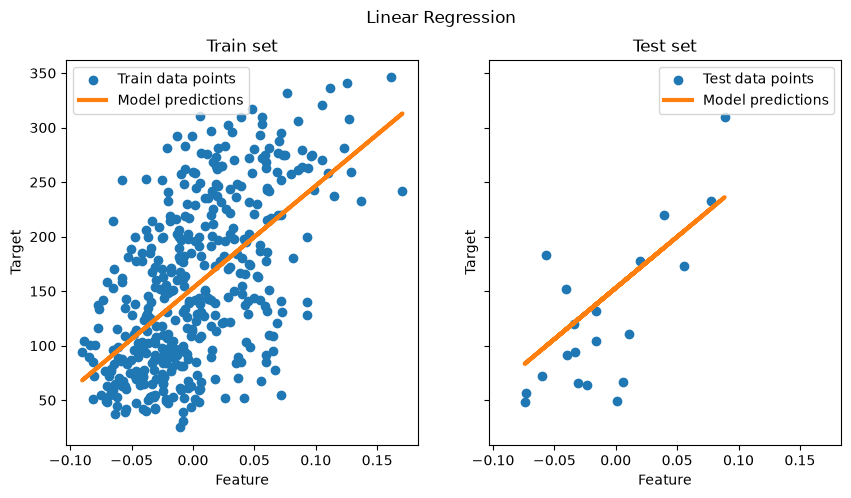

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10,5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label='Train data points')
ax[0].plot(
    X_train,
    reg_model.predict(X_train),
    linewidth=3,
    color='tab:orange',
    label='Model predictions',
)
ax[0].set(xlabel='Feature',ylabel='Target', title='Train set')
ax[0].legend()

ax[1].scatter(X_test, y_test, label='Test data points')
ax[1].plot(
    X_test, 
    reg_model.predict(X_test),
    linewidth=3,
    color='tab:orange',
    label="Model predictions"
)
ax[1].set(xlabel='Feature', ylabel='Target', title='Test set')
ax[1].legend()
fig.suptitle('Linear Regression')
plt.show()

#### Let's try with all the features

In [22]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

regressor = linear_model.LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared score: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 0.07
R-squared score: 0.69


The mean squared error and r-squared are way smaller when we use all the features

Ordinary Least Square and Ridge Regression Variance

In [ ]:
import numpy as np


X_train = np.c_[0.5, 1].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

classifiers = dict(
    ols=linear_model.LinearRegression(), ridge=linear_model.Ridge(alpha=0.1)
)

for name, clf in classifiers.item():
    fig, ax = plt.subplots(figsize=(4,3))
    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2,1)) + X_train
        clf.fit(this_X, y_train)
        

array([[0.5],
       [1. ]])